In [1]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn.functional as F
import seaborn as sns
import random
import pickle
import matplotlib.gridspec as gridspec



from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr
from scipy.stats import rankdata
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


from Bio import pairwise2
from Bio.Seq import Seq
from Bio.Align import substitution_matrices
from Bio import SeqIO

from random import sample

from utils_for_analysis import (
    calculate_ss_for_df_and_factors,
    load_df_all,
    load_df_with_budget,
    discretized_parameter_scale,
    xlabel_dict,
    ylabel_dict,
    title_fontsize,
    label_fontsize,
    tick_fontsize,
    legend_fontsize,
    original_parameter_scale,
    color_map,
    fix_ticks,
    get_labels,
    positions,
    num_muts_column_name,
    DATASET_PATHS
)


/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [ ]:

def get_relevant_columns_gfp_protgym(df, first_col, last_col):
    si = np.where(df.columns == first_col)[0][0]
    ei = np.where(df.columns == last_col)[0][0]+1
    return df.columns[si:ei]

def nmt_relevant_columns(df):
    si = np.where(df.columns == "1")[0][0]
    ei = np.where(df.columns == "272")[0][0]+1
    positions_with_mutations =  np.array([len(pd.unique(df.iloc[:,i])) > 1 for i in range(si,ei)])
    return df.columns[si:ei][positions_with_mutations]

def get_relevant_columns(dataset, df):
    cols = get_relevant_columns_gfp_protgym(df, positions[dataset][0], positions[dataset][1])
    return cols



# --- OHE Feature Creation ---
def get_one_hot_encoding(sdf, relevant_columns):
    one_hot_encoding = pd.get_dummies(sdf[relevant_columns])
    return one_hot_encoding

datasets_and_activity = {
    "gcn4": {"path": "./data/gcn4/gcn4.csv", "activity_col": "activity"},
    "pard3": {"path": "./data/pard3/pard3.csv", "activity_col": "activity"},
    "pte": {"path": "./data/pte/pte.csv", "activity_col": "p-nitrophenyl_octanoate"},
    "nmt": {"path": "./data/nmt/nmt_full_seq.csv", "activity_col": "activity"},
    "lov": {"path": "./data/lov/lov.csv", "activity_col": "activity"},
    "gfp": {"path": "./data/gfp/gfp_dataset_10mut.csv", "activity_col": "inactive"},
    "aamyl": {"path": "./data/aamyl/aamyl.csv", "activity_col": "activity"},
    "trpb": {"path": "./data/trpb/trpb.csv", "activity_col": "activity"},
    "his": {"path": "./data/his/his.csv", "activity_col": "activity"},
    "casp": {"path": "./data/casp/casp.csv", "activity_col": "activity"}
}

names_dict = {
    "esm2_t6_8M_UR50D": "ESM2 (8m)", 
    "esm2_t12_35M_UR50D": "ESM2 (35m)", 
    "esm2_t30_150M_UR50D": "ESM2 (150m)", 
    "esm2_t33_650M_UR50D" : "ESM2 (650m)",
    "pssm": "PSSM"
}





In [ ]:
dataset_order = ["his", "casp", "trpb", "aamyl", "gfp","pard3", "pte", "gcn4", "nmt", "lov"]

In [ ]:
for dataset in ["pte"]:    
    dataset_path = DATASET_PATHS[dataset]
    df = pd.read_csv(dataset_path)
    wt_seq = df[df["num_muts"] == 0]["full_seq"].iloc[0]
    # get one-hot encoding for relevant columns
    relevant_columns = get_relevant_columns(dataset, df)
    ohe = get_one_hot_encoding(df, relevant_columns)
    ohe_columns = ohe.columns
    onehot = ohe.to_numpy().astype(int)
    nmuts = df["num_muts"]

In [ ]:
emb = torch.load("/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pte/embeddings/esm_8m/embeddings.pt")
mean_emb = emb.mean(dim=1)

/tmp/ipykernel_3783535/3155173919.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  emb = torch.load("/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/noteboo

In [8]:
ind = np.random.choice(np.arange(0, len(mean_emb)), size=250, replace=False)

# ind = np.where(nmuts <= 3)[0]
# len(ind)

In [9]:


# Normalize the embeddings to unit vectors
esm_embeddings_norm = F.normalize(mean_emb[ind], p=2, dim=1)
# Compute pairwise cosine similarity
cosine_similarity_matrix = esm_embeddings_norm @ esm_embeddings_norm.T
cosine_similarity_matrix


# Flatten each sequence to 1D for Hamming distance
if isinstance(onehot, torch.Tensor):
    onehot_np = onehot.cpu().numpy()
else:
    onehot_np = onehot

onehot_np = onehot_np[ind]
n_seq = onehot_np.shape[0]
flat_onehot = onehot_np.reshape(n_seq, -1)
# Compute pairwise Hamming distance matrix (fraction of differing bits)
hamming_dist_matrix = squareform(pdist(flat_onehot, metric="hamming"))
hamming_dist_matrix



array([[0.  , 0.05, 0.05, ..., 0.04, 0.05, 0.09],
       [0.05, 0.  , 0.04, ..., 0.05, 0.05, 0.09],
       [0.05, 0.04, 0.  , ..., 0.04, 0.05, 0.09],
       ...,
       [0.04, 0.05, 0.04, ..., 0.  , 0.05, 0.09],
       [0.05, 0.05, 0.05, ..., 0.05, 0.  , 0.09],
       [0.09, 0.09, 0.09, ..., 0.09, 0.09, 0.  ]])

-0.767136221767299


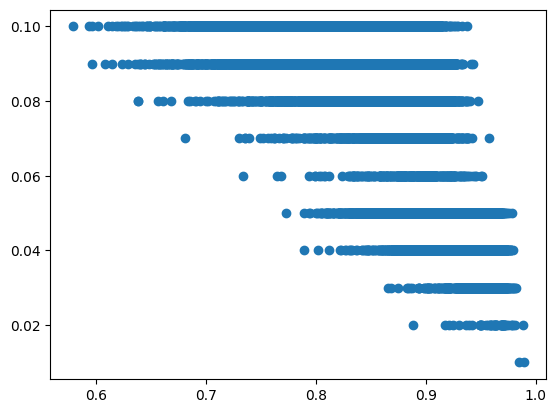

In [10]:

spearmanr(1 - cosine_similarity_matrix.flatten(), hamming_dist_matrix.flatten())


idx = np.triu_indices_from(cosine_similarity_matrix, k=1)
rho, _ = spearmanr(cosine_similarity_matrix[idx], hamming_dist_matrix[idx])

print(rho)

plt.scatter(cosine_similarity_matrix[idx], hamming_dist_matrix[idx])

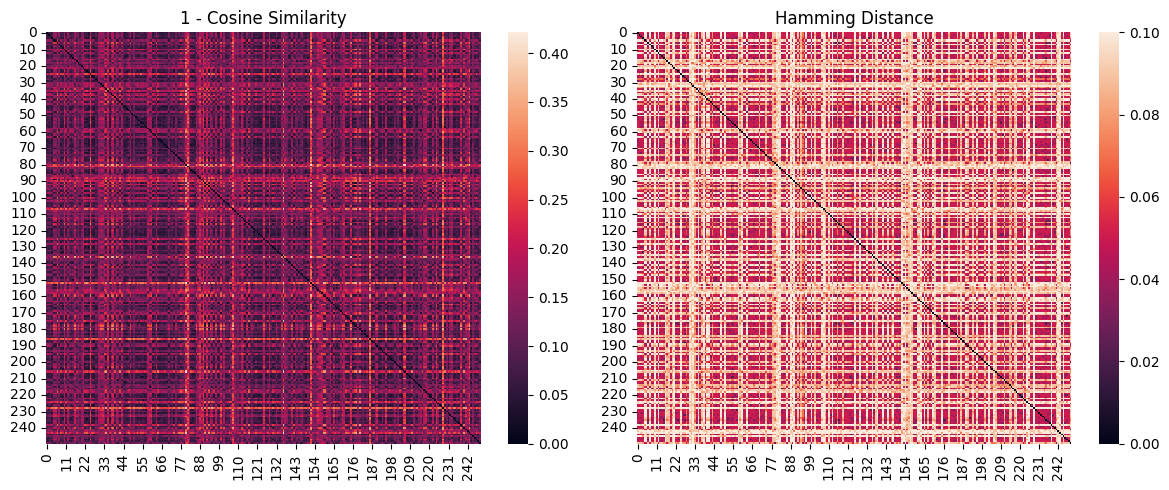

In [11]:
from sklearn.preprocessing import minmax_scale


cos_sim = 1 - cosine_similarity_matrix
ham_sim = hamming_dist_matrix
#cos_sim = minmax_scale(cos_sim.flatten(), axis=0).reshape(cosine_similarity_matrix.shape)
#ham_sim = minmax_scale(ham_sim.flatten(), axis=0).reshape(hamming_dist_matrix.shape)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cos_sim, ax=axs[0])
axs[0].set_title("1 - Cosine Similarity")
sns.heatmap(ham_sim, ax=axs[1])
axs[1].set_title("Hamming Distance")
plt.tight_layout()
plt.show()

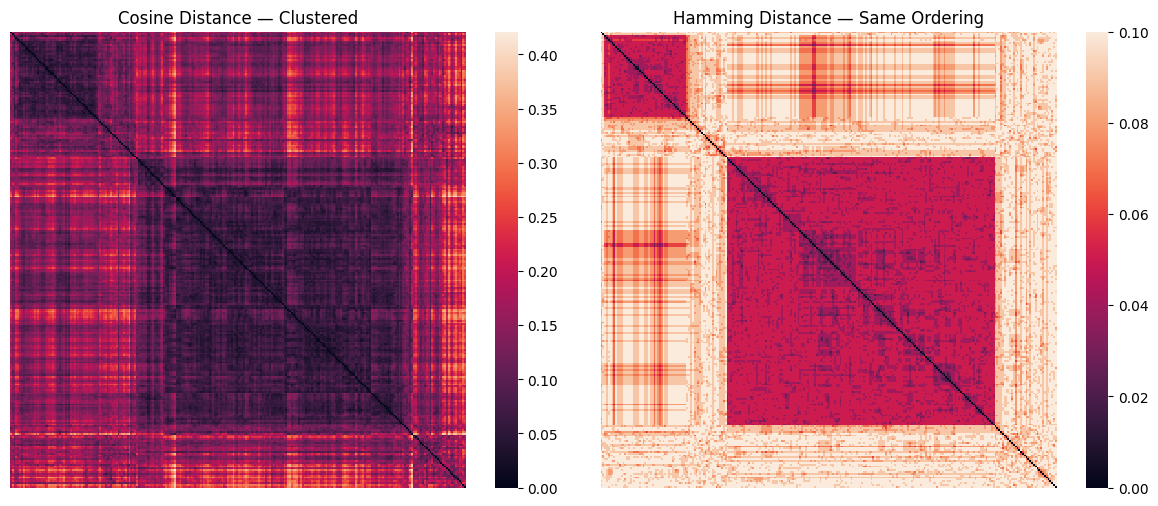

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from sklearn.preprocessing import minmax_scale

cos_dist = np.asarray(1 - cosine_similarity_matrix, dtype=float)
ham_dist = np.asarray(hamming_dist_matrix, dtype=float)

assert cos_dist.shape == ham_dist.shape
assert cos_dist.ndim == 2
assert cos_dist.shape[0] == cos_dist.shape[1]

cos_dist = np.nan_to_num(cos_dist, nan=0.0, posinf=1.0, neginf=0.0)
ham_dist = np.nan_to_num(ham_dist, nan=0.0, posinf=1.0, neginf=0.0)

cos_dist = (cos_dist + cos_dist.T) / 2
ham_dist = (ham_dist + ham_dist.T) / 2

cos_dist = np.clip(cos_dist, 0, None)
ham_dist = np.clip(ham_dist, 0, None)

np.fill_diagonal(cos_dist, 0)
np.fill_diagonal(ham_dist, 0)


# Normalize the two distances before combining them
cos_scaled = minmax_scale(cos_dist.ravel()).reshape(cos_dist.shape)
ham_scaled = minmax_scale(ham_dist.ravel()).reshape(ham_dist.shape)

# Equal-weight consensus distance
combined_dist = 0.5 * cos_scaled + 0.5 * ham_scaled
np.fill_diagonal(combined_dist, 0)


# Hierarchical clustering from the precomputed consensus distance
condensed_dist = squareform(combined_dist, checks=False)

Z = linkage(
    condensed_dist,
    method="average",
    optimal_ordering=True,
)

order = leaves_list(Z)


# Apply the same ordering to both matrices
cos_clustered = cos_dist[np.ix_(order, order)]
ham_clustered = ham_dist[np.ix_(order, order)]


fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cos_clustered,
    ax=axs[0],
    square=True,
    xticklabels=False,
    yticklabels=False,
)
axs[0].set_title("Cosine Distance — Clustered")

sns.heatmap(
    ham_clustered,
    ax=axs[1],
    square=True,
    xticklabels=False,
    yticklabels=False,
)
axs[1].set_title("Hamming Distance — Same Ordering")

plt.tight_layout()
plt.show()

In [21]:
cosine_similarity_matrix.shape

torch.Size([770, 770])

In [ ]:


onehot = onehot.astype(float)
cv = KFold(n_splits=5, shuffle=True, random_state=0)

X = mean_emb
Z = onehot
model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-4, 4, 25))
)

Z_hat = cross_val_predict(model, X, Z, cv=cv)

numerator = ((Z - Z_hat) ** 2).sum()
denominator = ((Z - Z.mean(axis=0)) ** 2).sum()

global_r2 = 1 - numerator / denominator

print(global_r2)


outer_cv = KFold(n_splits=5, shuffle=True, random_state=0)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=1)

alphas = np.logspace(-4, 4, 25)
Z_oof = np.empty_like(Z, dtype=float)

for train_idx, test_idx in outer_cv.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    Z_train = Z[train_idx]

    pipeline = Pipeline([
        ("scale", StandardScaler()),
        ("ridge", Ridge())
    ])

    search = GridSearchCV(
        pipeline,
        param_grid={"ridge__alpha": alphas},
        scoring="neg_mean_squared_error",
        cv=inner_cv,
        n_jobs=-1
    )

    search.fit(X_train, Z_train)
    Z_oof[test_idx] = search.predict(X_test)

feature_r2 = r2_score(
    Z,
    Z_oof,
    multioutput="raw_values"
)

weighted_r2 = r2_score(
    Z,
    Z_oof,
    multioutput="variance_weighted"
)

print("Variance-weighted R²:", weighted_r2)
print("Mean feature R²:", np.mean(feature_r2))
print("Median feature R²:", np.median(feature_r2))
print("Feature R² percentiles:",
      np.percentile(feature_r2, [0, 5, 25, 50, 75, 95, 100]))

0.7908496245988088
